In [1]:
import logging
import sys
logging.basicConfig(stream = sys.stdout, level = logging.INFO)
import matplotlib.pyplot as plt
import pandas as pd
from simpy_ejector.useCases import ejectorSimulator
from simpy_ejector import fluidProp

In [2]:
# load Refprop for your fluid:
fluid = "R1233zdE"
RP = fluidProp.setup(fluid)

In [3]:
# set up geometry parameters:
params = { "Rin": 1.5, "Rt": 0.29, "Rout": 0.87, "gamma_conv": 15.0, "gamma_div" : 6.0, "Dmix": 2.67,
           "Pprim": 2007, "hprim" : 365.5, "hsuc": 437.1, "Psuc" : 276.3 , "A_suction_inlet" : 16 ,
           "mixerLen": 12 , "gamma_diffusor": 2.5, "diffuserLen": 10}

In [4]:
primQ = fluidProp.getTD(RP, hm= params["hprim"], P=params["Pprim"] )
params["Tprim"] = primQ['T']
params["Tsuc"] = fluidProp.getTD(RP, hm= params["hsuc"], P=params["Psuc"] )['T']

In [5]:
params["mixingParams"] = {'massExchangeFactor': 2.e-4, 'dragFactor': 0.01, 'frictionInterface': 0.0,
                        'frictionWall': 0.0015}

In [6]:
params

{'Rin': 1.5,
 'Rt': 0.29,
 'Rout': 0.87,
 'gamma_conv': 15.0,
 'gamma_div': 6.0,
 'Dmix': 2.67,
 'Pprim': 2007,
 'hprim': 365.5,
 'hsuc': 437.1,
 'Psuc': 276.3,
 'A_suction_inlet': 16,
 'mixerLen': 12,
 'gamma_diffusor': 2.5,
 'diffuserLen': 10,
 'Tprim': 378.10377364228407,
 'Tsuc': 321.15276023538735,
 'mixingParams': {'massExchangeFactor': 0.0002,
  'dragFactor': 0.01,
  'frictionInterface': 0.0,
  'frictionWall': 0.0015}}

In [7]:
esim = ejectorSimulator.ejectorSimu(params,fluid)

INFO:root:Primary nozzle: inlet Radius 1.5 cm,
 Throat radius 0.29 cm 
 convergent lenght 4.515781477158342 cm
INFO:root:Primary nozzle: Outlet Radius 0.87 cm,
 divergent length 5.5183313834491
INFO:root:Primary nozzle: Rin =1.5, Rout = 0.87 Lcon = 4.515781477158342, Rt = 0.29 cm,
 converg Len 4.51578 divergent length 5.51833 
INFO:root:mixer start 11.134112860607441 cm, diffuser length 10.0 cm
friction of the flow calc set to 0.01


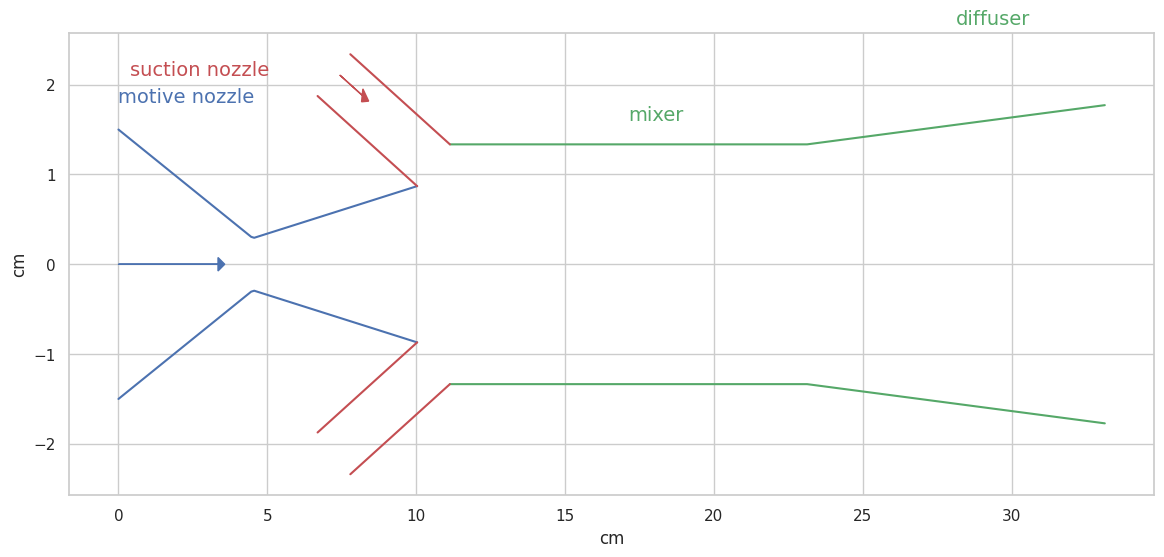

In [8]:
ejplot = esim.ejector.draw()

In [9]:
## calculate the primary mass flow rate:
esim.calcPrimMassFlow()

INFO:root:Primary nozzle: inlet Radius 1.5 cm,
 Throat radius 0.29 cm 
 convergent lenght 4.515781477158342 cm
INFO:root:Primary nozzle: Outlet Radius 0.87 cm,
 divergent length 5.5183313834491
INFO:root:Primary nozzle: Rin =1.5, Rout = 0.87 Lcon = 4.515781477158342, Rt = 0.29 cm,
 converg Len 4.51578 divergent length 5.51833 
INFO:root:mixer start 11.134112860607441 cm, diffuser length 10.0 cm
friction of the flow calc set to 0.01
INFO:root: prim press 2007 kPa, sec press 276.3 kPa 
{'massflow': 0.22070509434070357}
INFO:root: x interval end reached xlast 9.973547312959822 +  dX 0.1 vs xend 10.034112860607442
INFO:root:solver finished in 128 iterations. final point xlast =10.034112860607442
{'massflow': 0.44141018868140713}
INFO:root: x interval end reached xlast 9.979025912667861 +  dX 0.1 vs xend 10.034112860607442
INFO:root:solver finished in 235 iterations. final point xlast =10.034112860607442
{'massflow': 0.8828203773628143}
INFO:root: x interval end reached xlast 9.995959794538

{'massflow': 1.1052497302530524}
3 dimensional Newton Raphson has not converged in 100 iterations
error = 0.0482305802228621
INFO:root:Newton root finding failed at 4.515082469853619 + 0.0006990073047230538
3 dimensional Newton Raphson has not converged in 100 iterations
error = 0.018037600885237908
INFO:root:Newton root finding failed at 4.515108571000426 + 0.0003114615877414338
INFO:root:update failed by 4.515108571000426 with dX=0.0003114615877414338. stop solver
INFO:root:mass conserving artificial kick: dv = 2.0 m/s, dp = -7.860669883053183 kPa
{'massflow': 1.1052497302530524}
3 dimensional Newton Raphson has not converged in 100 iterations
error = 0.0482305802228621
INFO:root:Newton root finding failed at 4.515082469853619 + 0.0006990073047230538
3 dimensional Newton Raphson has not converged in 100 iterations
error = 0.018037600885237908
INFO:root:Newton root finding failed at 4.515108571000426 + 0.0003114615877414338
INFO:root:update failed by 4.515108571000426 with dX=0.000311

/volume1/PROJECTS/MATACHANA/robert/python/simpy_steamEjector/src/simpy_ejector/flowSolver.py:288: RuntimeWarning: divide by zero encountered in divide
  'c': speed_sound, 'mach': sol[:, 1] / speed_sound, 'quality': quality})
/volume1/PROJECTS/MATACHANA/robert/python/simpy_steamEjector/src/simpy_ejector/nozzleSolver.py:419: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  sol_full = sol_1.append(sol_2.iloc[1:], ignore_index=True)


By the motive nozzle exit:
 x           10.034113
v          117.106105
p          286.210404
h          358.726960
d           39.641733
c            0.000000
mach              inf
quality      1.000000
Name: 5211, dtype: float64


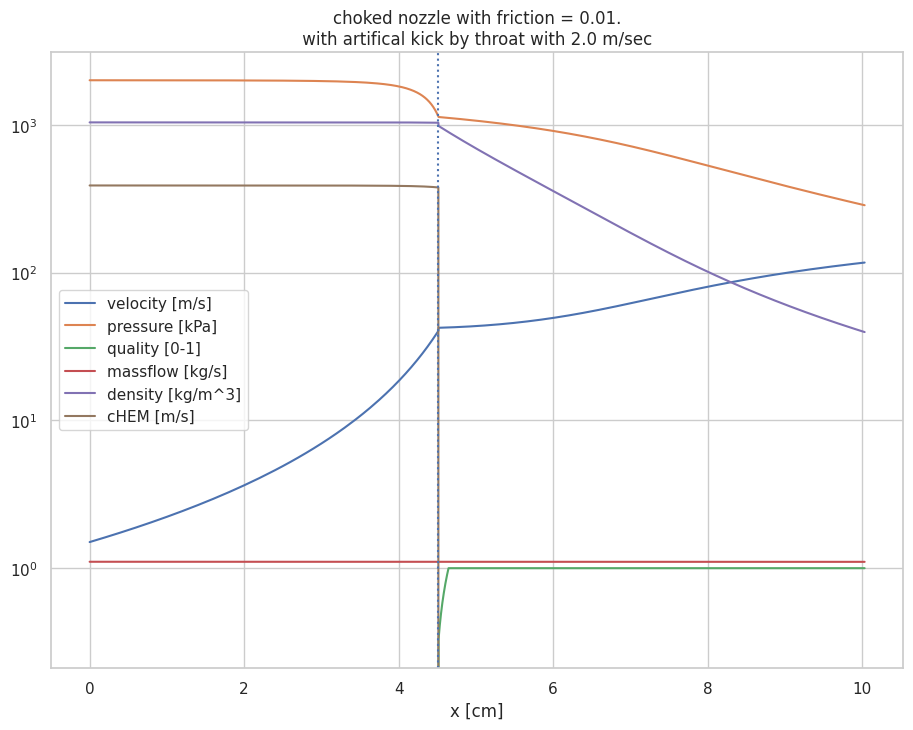

In [10]:
res_crit = esim.motiveSolver()
print(f"By the motive nozzle exit:\n {res_crit.iloc[-1]}")

In [11]:
esim.premix(res_crit) # this sets the mixer, that is needed for the mixing calculation
print(f"suction MFR [g/s] {round(esim.mixerin['massFlowSecond'],3)}")

critical flow nozzle outlet quantities
               5211
x         10.034113
v        117.106105
p        286.210404
h        358.726960
d         39.641733
c          0.000000
mach            inf
quality    1.000000
INFO:root:suction flow by inlet Dens 14.801383924045858 g/l, quality 0.0
INFO:root:calculation of single-chocking subcritical mode incl. suction mass flow rate calculations
{'Tsi': 321.15276023538735, 'psi': 276.3, 'massFlowPrim': 1103.8766545125584, 'ho': 358.7269604168832, 'vo': 117.10610457760396, 'so': 1.53496479921568, 'Am': 5.599024967044069}
INFO:root:solving equation for 10 variables in solvePreMixSingleChoke with parameters:
 {'Tsi': 321.15276023538735, 'psi': 276.3, 'massFlowPrim': 1103.8766545125584, 'ho': 358.7269604168832, 'vo': 117.10610457760396, 'so': 1.53496479921568, 'Am': 5.599024967044069, 'sp': 1.53496479921568, 'Dsi': 14.801383924045858, 'hsi': 468.46267330149107, 'hst': 468.46267330149107, 'sst': 1.8774549289299671, 'Asi': 16}
INFO:root:premix calc

In [12]:
esim.mixersolve()

INFO:root:diffuser outlet
INFO:root:primary 37.98 m/s with vapor q: 1.0. MFR 1.12
INFO:root:secondary 4.8 m/s with vapor q: 1.0. MFR 0.07
INFO:root:total q 1.0


In [13]:
esim.massFlowCheck()
outletValues = esim.solMix.iloc[-1].to_dict() # .transpose()

average_h = (outletValues["MFRp"] * outletValues["hp"] + outletValues["MFRs"] * outletValues["hs"])/ (outletValues["MFRp"] + outletValues["MFRs"] )
print(f"Ejector outlet specific enthalpy {round(average_h,3)} kJ/kg, pressure {round(outletValues['p']*1e-2,3)} bar,"
      f" vapor quality {round(outletValues['q_average'],3)}  ")

esim.plotMixSolution(res_crit, esim.solMix, "simpy_ejector 1D Ejector flow solution")

AttributeError: 'ejectorSimu' object has no attribute 'RP'